# Model EDA — Hierarchical IDS

This notebook analyses model behaviour across hierarchical datasets:

- M1: Attack vs Non-Attack  
- M2: Natural 3-Class  
- M3: Attack 3-Class  
- M4: Data Injection (Internal)  
- M5: Remote Tripping (Internal)  
- M6: Relay Setting Change (Internal)

Goal:
- Understand class distributions
- Identify key features
- Examine feature separability

In [211]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [212]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L2 Maint R3&R4 Disabled"
}

SCENARIO_SHORT = {

# Natural Faults
1:  "F L1 10–19%",
2:  "F L1 20–79%",
3:  "F L1 80–90%",
4:  "F L2 10–19%",
5:  "F L2 20–79%",
6:  "F L2 80–90%",

# Data Injection
7:  "DI L1 10–19%",
8:  "DI L1 20–79%",
9:  "DI L1 80–90%",
10: "DI L2 10–19%",
11: "DI L2 20–79%",
12: "DI L2 80–90%",

# Maintenance
13: "Maint L1",
14: "Maint L2",

# Remote Tripping
15: "RT R1",
16: "RT R2",
17: "RT R3",
18: "RT R4",
19: "RT R1&R2",
20: "RT R3&R4",

# Relay Setting Change
21: "RSC L1 R1 10–19%",
22: "RSC L1 R1 20–90%",
23: "RSC L1 R2 10–49%",
24: "RSC L1 R2 50–79%",
25: "RSC L1 R2 80–90%",
26: "RSC L2 R3 10–19%",
27: "RSC L2 R3 20–49%",
28: "RSC L2 R3 50–90%",
29: "RSC L2 R4 10–79%",
30: "RSC L2 R4 80–90%",

# Dual Relay Setting Change
35: "RSC L1 R1&R2 (10–49%)",
36: "RSC L1 R1&R2 (50-90%)",
37: "RSC L2 R3&R4 (10–49%)",
38: "RSC L2 R3&R4 (50-90%)",

# Maintenance + Relay Setting Change
39: "Maint+RSC L1 R1&R2",
40: "Maint+RSC L1 R1&R2",

# Normal
41: "Normal"
}

In [213]:
DATA_DIR = "../data/datasets_hierarchical"

datasets = {
    "M1": "M1_Attack_vs_NonAttack_clean.csv",
    "M2": "M2_Natural_3Class_clean.csv",
    "M3": "M3_Attack_3Class_clean.csv",
    "M4": "M4_DataInjection_Internal_clean.csv",
    "M5": "M5_RemoteTripping_Internal_clean.csv",
    "M6": "M6_RelaySetting_Internal_clean.csv"
}

loaded = {}

for name, file in datasets.items():
    df = pd.read_csv(f"{DATA_DIR}/{file}")
    df.columns = df.columns.str.strip()
    loaded[name] = df
    print(name, df.shape)

M1 (78377, 134)
M2 (22714, 134)
M3 (55663, 134)
M4 (9582, 134)
M5 (8737, 134)
M6 (37344, 134)


In [214]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

CLASS_PALETTE = ["#5ab4ac", "#d8b365", "#8da0cb", "#fc8d62", "#66c2a5"]

def add_bar_labels(ax, total):
    max_height = max(p.get_height() for p in ax.patches)

    for p in ax.patches:
        count = int(p.get_height())
        perc = 100 * count / total

        if p.get_height() < 0.2 * max_height:
            ax.annotate(f"{count}\n({perc:.1f}%)",
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha="center", va="bottom", fontsize=14, fontweight="bold")
        else:
            ax.annotate(f"{count}\n({perc:.1f}%)",
                        (p.get_x() + p.get_width()/2, p.get_height()/2),
                        ha="center", va="center", color="white", fontsize=14, fontweight="bold")
            

def get_top_correlations(df, target_col="label", top_k=10):

    exclude = ["marker", "label", "label_name"]
    
    numeric_cols = [
        c for c in df.select_dtypes(include="number").columns
        if c not in exclude
    ]

    corr = df[numeric_cols].corrwith(df[target_col])
    corr = corr.abs().sort_values(ascending=False)

    return corr.head(top_k).index.tolist()

In [215]:
def eda_basic(df, target="label", target_name="label_name", name="Dataset"):

    print("\n" + "="*60)
    print(f"EDA: {name}")
    print("="*60)

    print(f"\nShape: {df.shape}")

    # --- DISTRIBUTION ---
    total = len(df)
    order = sorted(df[target_name].unique())

    plt.figure(figsize=(6,4))
    ax = sns.countplot(
        x=df[target_name],
        order=order,
        palette="Set2"
    )

    add_bar_labels(ax, total)

    plt.title(f"{name} | Distribution", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

    # --- TOP FEATURES ---
    top10 = get_top_correlations(df, target)

    print(f"\nTop 10 features used for plots ({name}):")
    print(top10)

    # 🔥 FILTER GOOD FEATURES (skip log + low-unique)
    good_features = []
    for f in top10:
        if "log" in f:
            continue
        if df[f].nunique() <= 2:
            continue
        good_features.append(f)

    # fallback (in case too strict)
    if len(good_features) < 3:
        good_features = top10

    selected = good_features[:3]

    # --- FEATURE PLOTS ---
    classes = sorted(df[target].unique())

    fig, axes = plt.subplots(1, 3, figsize=(15,4))

    for i, f in enumerate(selected):

        print(f"\nFeature {i+1}: {f}")

        # 🔥 auto choose plot
        if df[f].nunique() <= 5:
            sns.boxplot(
                x=df[target_name],
                y=df[f],
                order=order,
                palette="Set2",
                ax=axes[i]
            )
        else:
            sns.violinplot(
                x=df[target_name],
                y=df[f],
                order=order,
                palette="Set2",
                inner="quartile",
                linewidth=1.5,
                cut=0,
                bw=0.3,
                scale="width",
                ax=axes[i]
            )

        axes[i].set_ylim(
            df[f].quantile(0.01),
            df[f].quantile(0.99)
        )

        # binary label naming
        if target == "label" and len(classes) == 2:
            axes[i].set_xticklabels(["Non-Attack", "Attack"])

        axes[i].set_title(f"{f}", fontsize=11, weight="bold")
        axes[i].set_ylabel(f)
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle(f"{name} | Top Feature Distributions", fontsize=13)
    plt.tight_layout()
    plt.show()

    return top10
    
def eda_level_3(df, name="Dataset", fig_width=10):

    target = "marker"

    if "marker_name" not in df.columns:
        df["marker_name"] = df["marker"].map(SCENARIO_SHORT)

    target_name = "marker_name"

    print("\n" + "="*60)
    print(f"EDA: {name}")
    print("="*60)

    print(f"\nShape: {df.shape}")

    # --- DISTRIBUTION ---
    counts = df[target].value_counts().sort_index()
    total = counts.sum()

    labels = [SCENARIO_SHORT.get(i, i) for i in counts.index]

    plt.figure(figsize=(fig_width, 4))

    ax = sns.barplot(
        x=labels,
        y=counts.values,
        palette="Set2",
        width=0.9
    )

    add_bar_labels(ax, total)

    plt.xticks(rotation=45, ha="right")
    plt.title(f"{name} | Distribution", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

    # --- TOP FEATURES ---
    top10 = get_top_correlations(df, target)

    print(f"\nTop 10 features used for plots ({name}):")
    print(top10)

    # 🔥 FILTER GOOD FEATURES
    good_features = []
    for f in top10:
        if "log" in f:
            continue
        if df[f].nunique() <= 2:
            continue
        good_features.append(f)

    if len(good_features) < 3:
        good_features = top10

    selected = good_features[:3]

    # --- FEATURE PLOTS ---
    classes = [SCENARIO_SHORT.get(i, i) for i in sorted(df[target].unique())]

    fig, axes = plt.subplots(1, 3, figsize=(fig_width, 4))

    for i, f in enumerate(selected):

        print(f"\nFeature {i+1}: {f}")

        if df[f].nunique() <= 5:
            sns.boxplot(
                x=df[target_name],
                y=df[f],
                order=classes,
                palette="Set2",
                ax=axes[i]
            )
        else:
            sns.violinplot(
                x=df[target_name],
                y=df[f],
                order=classes,
                palette="Set2",
                inner="quartile",
                linewidth=1.5,
                cut=0,
                bw=0.3,
                scale="width",
                ax=axes[i]
            )

        axes[i].set_ylim(
            df[f].quantile(0.01),
            df[f].quantile(0.99)
        )

        axes[i].set_title(f"{f}", fontsize=11, weight="bold")
        axes[i].set_ylabel(f)
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)

    plt.suptitle(f"{name} | Top Feature Distributions", fontsize=13)
    plt.tight_layout()
    plt.show()

    return top10


EDA: M1 - Attack vs Non-Attack

Shape: (78377, 134)


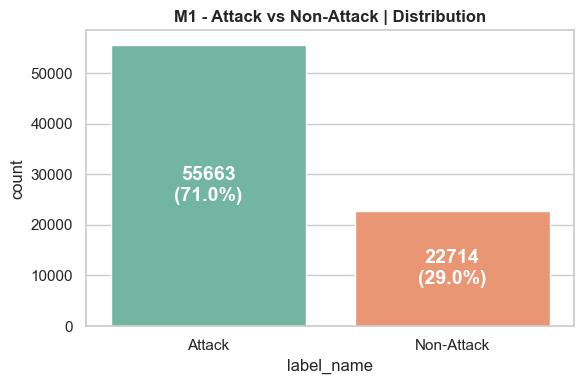


Top 10 features used for plots (M1 - Attack vs Non-Attack):
['R4-PM2:V', 'R4-PM7:V', 'relay3_log', 'R1-PA:ZH', 'R4-PA:ZH', 'R4-PM3:V', 'R4-PM1:V', 'R3-PM3:V', 'relay2_log', 'R2-PA:Z']

Feature 1: R4-PM2:V

Feature 2: R4-PM7:V

Feature 3: R1-PA:ZH


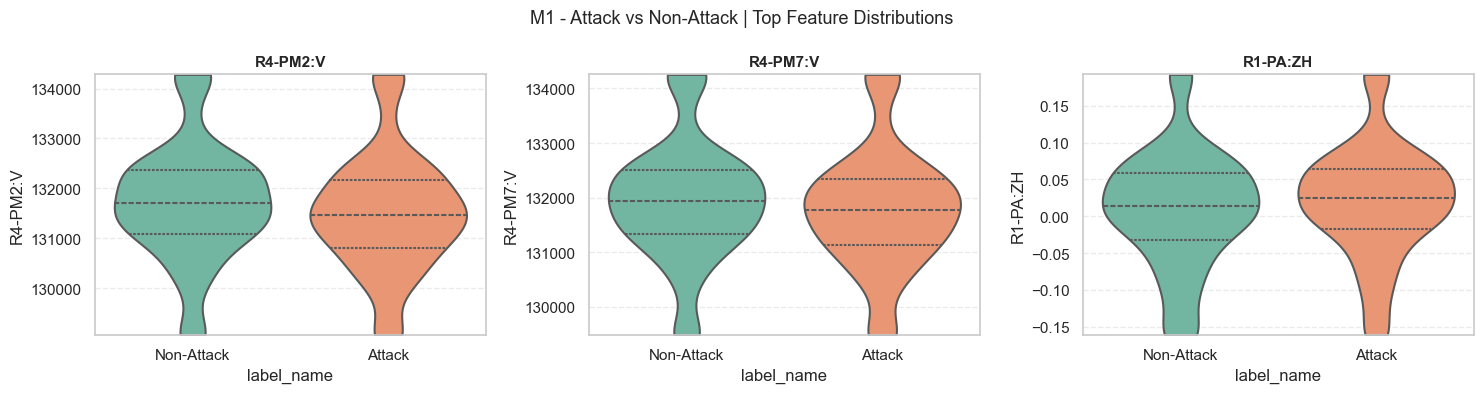

In [216]:
# ============================================================
# M1 — EDA
# ============================================================
top10 = eda_basic(loaded["M1"], name="M1 - Attack vs Non-Attack")

## Insight: ##
### Voltage measurements (especially from Relay 4) and impedance features are highly effective in distinguishing attack vs non-attack conditions, indicating that attacks significantly alter electrical signal patterns. ###


EDA: M2 - Natural 3-Class

Shape: (22714, 134)


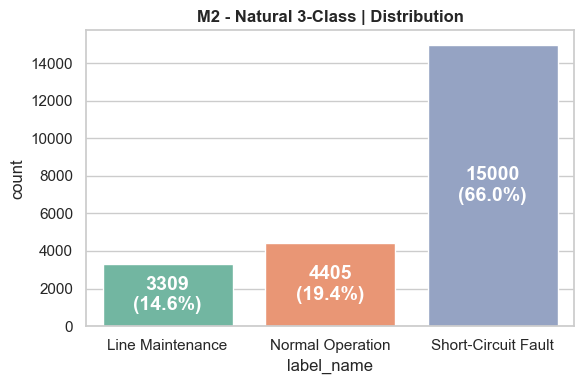


Top 10 features used for plots (M2 - Natural 3-Class):
['R3-PM12:I', 'R4-PM12:I', 'R2-PM11:I', 'R1-PM11:I', 'R1-PM12:I', 'R2-PM12:I', 'R4-PM11:I', 'R3-PM11:I', 'R4-PM2:V', 'R2-PM3:V']

Feature 1: R3-PM12:I

Feature 2: R4-PM12:I

Feature 3: R2-PM11:I


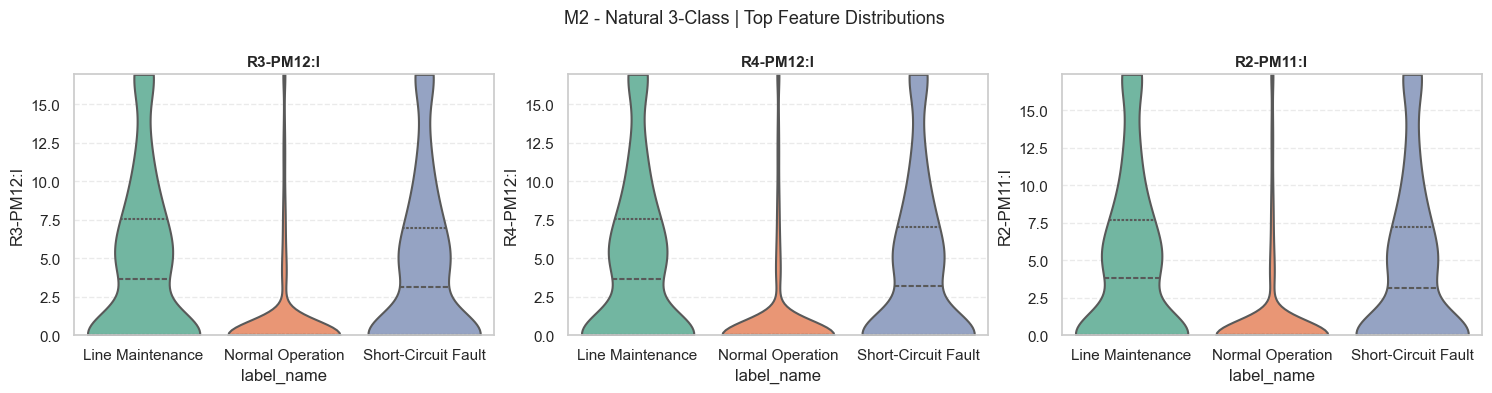

In [204]:
# ============================================================
# M2 — EDA
# ============================================================
top10 = eda_basic(loaded["M2"], name="M2 - Natural 3-Class")

## Insight: ##
### Natural system behaviors (faults vs normal vs maintenance) are better distinguished by current signals rather than voltage, suggesting that current flow variations are key indicators of physical system states. ###


EDA: M3 - Attack 3-Class

Shape: (55663, 134)


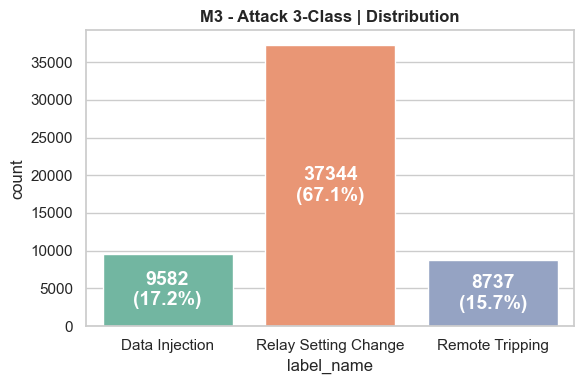


Top 10 features used for plots (M3 - Attack 3-Class):
['relay2_log', 'relay3_log', 'R4-PM2:V', 'R2-PA:Z_inf_flag', 'R3-PM3:V', 'R3-PA:Z_inf_flag', 'R4-PM7:V', 'R3-PM1:V', 'relay1_log', 'R1-PA:Z_inf_flag']

Feature 1: R4-PM2:V

Feature 2: R3-PM3:V

Feature 3: R4-PM7:V


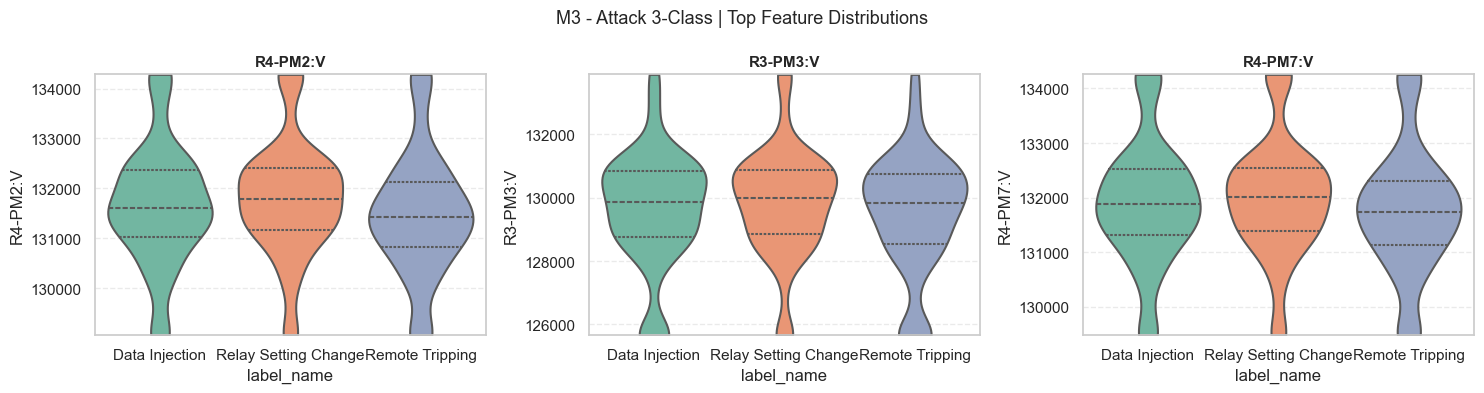

In [205]:
# ============================================================
# M3 — EDA
# ============================================================
top10 = eda_basic(loaded["M3"], name="M3 - Attack 3-Class")

## Insight: ##
### Attack classification requires a combination of cyber indicators (relay logs) and physical measurements (voltage), highlighting the hybrid nature of cyber-physical attacks. ###


EDA: M4 - Data Injection

Shape: (9582, 135)


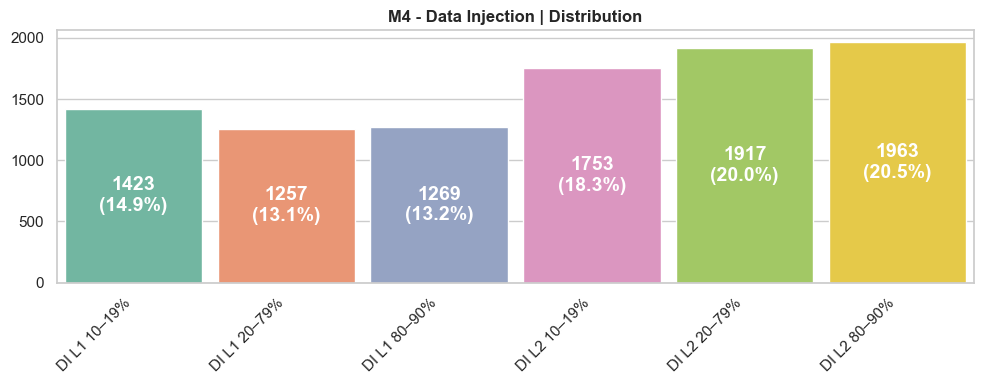


Top 10 features used for plots (M4 - Data Injection):
['R4-PM2:V', 'R1-PM2:V', 'R1-PA:ZH', 'R4-PM7:V', 'R2-PM6:I', 'R1-PM6:I', 'R1-PA:Z_inf_flag', 'R2-PA:Z_inf_flag', 'relay2_log', 'relay1_log']

Feature 1: R4-PM2:V

Feature 2: R1-PM2:V

Feature 3: R1-PA:ZH


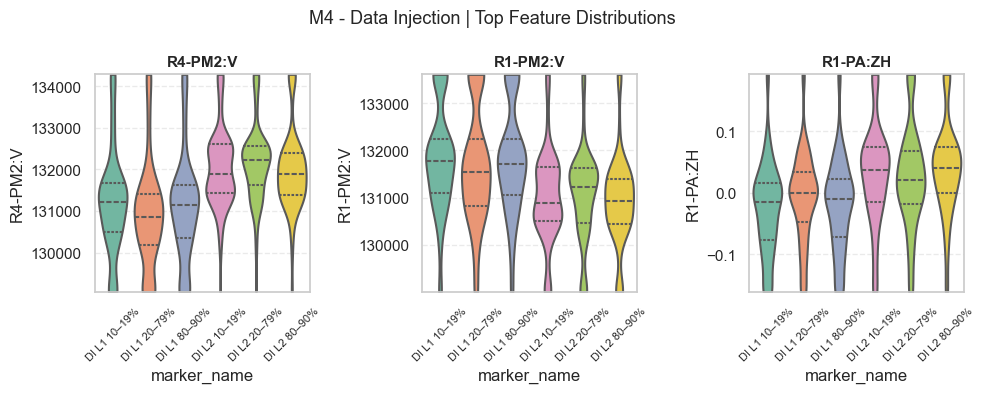

In [219]:
# ============================================================
# M4 — EDA
# ============================================================
top10 = eda_level_3(loaded["M4"], name="M4 - Data Injection")

## Insight: ##
### Data injection attacks mimic legitimate fault patterns, making them harder to distinguish; however, subtle inconsistencies in voltage and impedance signals enable discrimination. ###


EDA: M5 - Remote Tripping

Shape: (8737, 135)


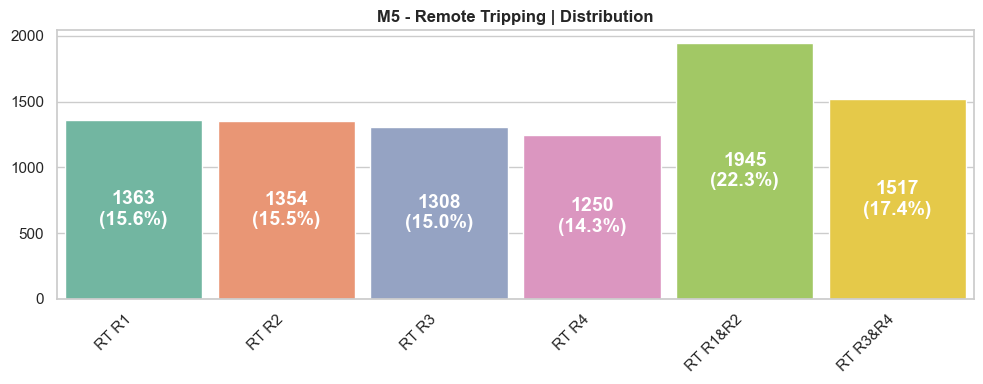


Top 10 features used for plots (M5 - Remote Tripping):
['R4-PM2:V', 'relay4_log', 'R4-PA:Z_inf_flag', 'R1-PA:ZH', 'R4-PM7:V', 'R2-PA6:IH', 'R3-PA6:IH', 'R1-PA6:IH', 'R4-PM3:V', 'R4-PM1:V']

Feature 1: R4-PM2:V

Feature 2: R1-PA:ZH

Feature 3: R4-PM7:V


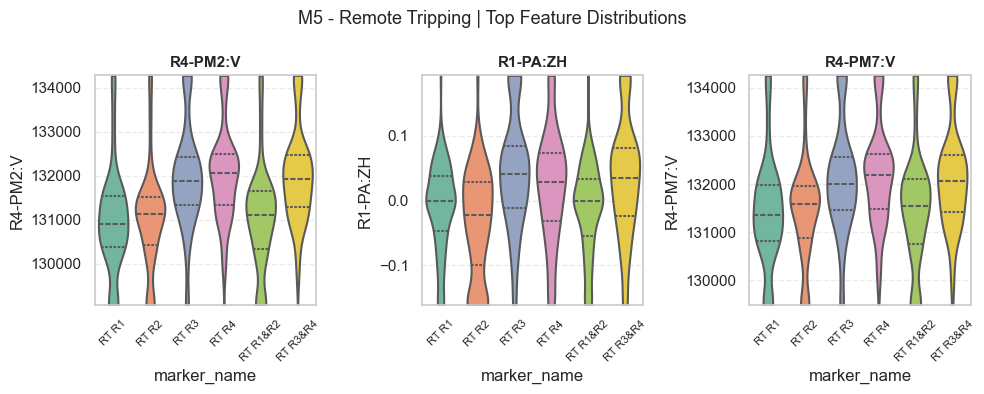

In [220]:
top10 = eda_level_3(loaded["M5"], name="M5 - Remote Tripping")

## Insight: ##
### Remote tripping attacks are strongly characterized by relay command anomalies, making relay log features highly informative for classification. ###


EDA: M6 - Relay Setting

Shape: (37344, 135)


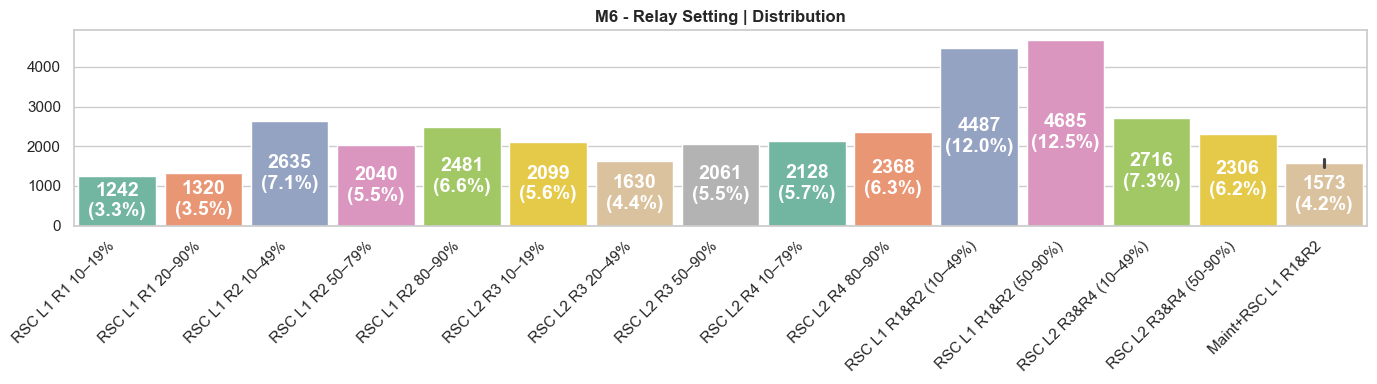


Top 10 features used for plots (M6 - Relay Setting):
['R2-PA:Z_inf_flag', 'R3-PM2:V', 'relay2_log', 'R1-PM2:V', 'R2-PM6:I', 'R2-PM3:V', 'R1-PM6:I', 'R2-PM10:I', 'R3-PA:Z_inf_flag', 'R2-PM5:I']

Feature 1: R3-PM2:V

Feature 2: R1-PM2:V

Feature 3: R2-PM6:I


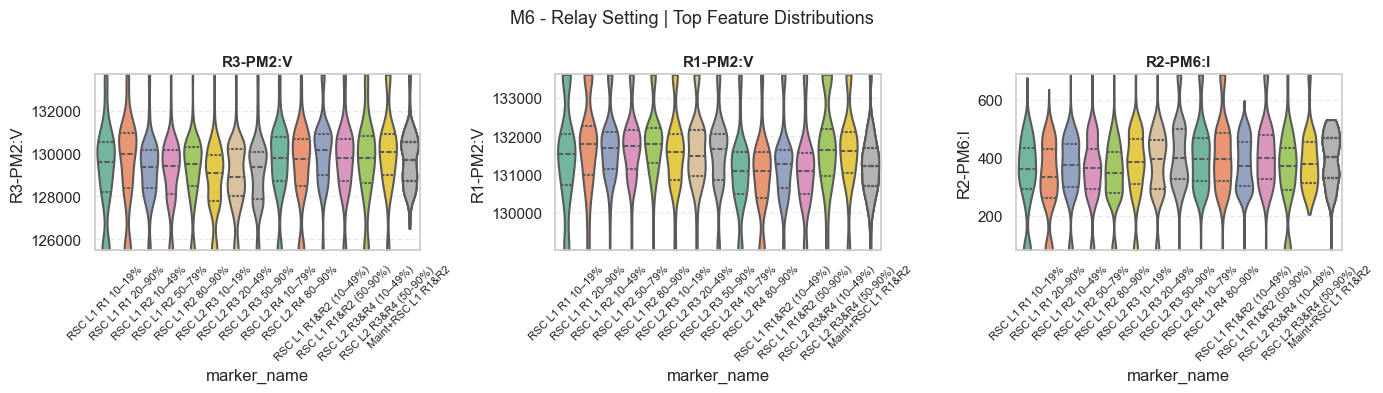

In [221]:
top10 = eda_level_3(loaded["M6"], name="M6 - Relay Setting", fig_width=14)

## Insight: ##
### Relay setting changes introduce abnormal impedance conditions (captured by Z_inf flags), making these features critical for detecting configuration tampering. ###

In [223]:
import numpy as np
import pandas as pd

# -------------------------------
# MAIN SUMMARY FUNCTION
# -------------------------------
def full_missing_summary(datasets_dict):
    summary_rows = []
    
    print("\n" + "="*70)
    print(" FULL NaN + INF SUMMARY (M1–M6)")
    print("="*70)
    
    for name, df in datasets_dict.items():
        numeric_df = df.select_dtypes(include='number')
        
        # --- TOTAL COUNTS ---
        total_values = numeric_df.size
        nan_count = numeric_df.isna().sum().sum()
        inf_count = np.isinf(numeric_df).sum().sum()
        
        nan_pct = 100 * nan_count / total_values
        inf_pct = 100 * inf_count / total_values
        
        # --- COLUMN BREAKDOWN ---
        nan_by_col = numeric_df.isna().sum()
        inf_by_col = pd.Series(np.isinf(numeric_df).sum(), index=numeric_df.columns)
        
        nan_cols = nan_by_col[nan_by_col > 0].sort_values(ascending=False)
        inf_cols = inf_by_col[inf_by_col > 0].sort_values(ascending=False)
        
        # --- PRINT SUMMARY ---
        print(f"\n--- {name} ---")
        print(f"Shape: {df.shape}")
        print(f"Total values: {total_values}")
        print(f"NaN count: {nan_count} ({nan_pct:.4f}%)")
        print(f"Inf count: {inf_count} ({inf_pct:.4f}%)")
        
        # --- PRINT COLUMN DETAILS ---
        if len(nan_cols) > 0:
            print("\nNaN Columns:")
            print(nan_cols.head(10))
        else:
            print("\n✔ No NaN values")
        
        if len(inf_cols) > 0:
            print("\n⚠ Inf Columns (Top):")
            print(inf_cols.head(10))
        else:
            print("\n✔ No Inf values")
        
        # --- STORE SUMMARY ---
        summary_rows.append({
            "Dataset": name,
            "Rows": df.shape[0],
            "Columns": df.shape[1],
            "Total Values": total_values,
            "NaN Count": nan_count,
            "NaN %": round(nan_pct, 4),
            "Inf Count": inf_count,
            "Inf %": round(inf_pct, 4)
        })
    
    # -------------------------------
    # FINAL TABLE
    # -------------------------------
    summary_df = pd.DataFrame(summary_rows)
    
    print("\n" + "="*70)
    print(" FINAL SUMMARY TABLE")
    print("="*70)
    print(summary_df)
    
    return summary_df


# -------------------------------
# RUN
# -------------------------------
summary_df = full_missing_summary(loaded)


 FULL NaN + INF SUMMARY (M1–M6)

--- M1 ---
Shape: (78377, 134)
Total values: 10424141
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

--- M2 ---
Shape: (22714, 134)
Total values: 3020962
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

--- M3 ---
Shape: (55663, 134)
Total values: 7403179
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

--- M4 ---
Shape: (9582, 135)
Total values: 1283988
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

--- M5 ---
Shape: (8737, 135)
Total values: 1170758
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

--- M6 ---
Shape: (37344, 135)
Total values: 5004096
NaN count: 0 (0.0000%)
Inf count: 0 (0.0000%)

✔ No NaN values

✔ No Inf values

 FINAL SUMMARY TABLE
  Dataset   Rows  Columns  Total Values  NaN Count  NaN %  Inf Count  Inf %
0      M1  78377      134      10424141          0    0.0         

In [224]:
# ============================================================
# FINAL EDA SUMMARY — FEATURE + INSIGHT TABLE (M1–M6)
# ============================================================

import pandas as pd
from IPython.display import display, Markdown

# -------------------------------
# FUNCTIONS
# -------------------------------

def get_top_features(df, target="label", top_k=5):
    exclude = ["marker", "label", "label_name"]
    
    numeric_cols = [
        c for c in df.select_dtypes(include="number").columns
        if c not in exclude
    ]
    
    corr = df[numeric_cols].corrwith(df[target]).abs().sort_values(ascending=False)
    return corr.head(top_k).index.tolist()


def remove_log_features(features):
    return [f for f in features if "log" not in f]


# -------------------------------
# MODEL META INFO
# -------------------------------

MODEL_INFO = {
    "M1": "Attack vs Non-Attack",
    "M2": "Natural 3-Class",
    "M3": "Attack 3-Class",
    "M4": "Data Injection",
    "M5": "Remote Tripping",
    "M6": "Relay Setting Change",
}

INSIGHT_TEXT = {
    "M1": "Voltage and impedance strongly separate attack vs non-attack states.",
    "M2": "Current features dominate natural system behavior classification.",
    "M3": "Combines cyber (relay logs) and physical signals for attack detection.",
    "M4": "Data injection mimics faults, making separation more difficult.",
    "M5": "Relay logs clearly indicate command-based attacks.",
    "M6": "Impedance anomalies reveal relay configuration changes.",
}


def detect_signal_type(features):
    text = " ".join(features)
    
    if "log" in text:
        return "Cyber + Physical"
    elif ":I" in text:
        return "Current"
    elif ":Z" in text or "ZH" in text:
        return "Impedance"
    elif ":V" in text:
        return "Voltage"
    else:
        return "Mixed"


# -------------------------------
# BUILD TABLE
# -------------------------------

rows = []

for name, df in loaded.items():
    top_features = get_top_features(df, top_k=5)
    no_log_features = remove_log_features(top_features)
    
    uses_log = any("log" in f for f in top_features)
    
    rows.append({
        "Model": name,
        "Task": MODEL_INFO[name],
        "Top Features": ", ".join(top_features),
        "Top Features (No Log)": ", ".join(no_log_features[:5]),
        "Dominant Signal": detect_signal_type(top_features),
        "Uses Cyber Features": "Yes" if uses_log else "No",
        "Key Insight": INSIGHT_TEXT[name]
    })

summary_table = pd.DataFrame(rows)

# -------------------------------
# DISPLAY (TABLE)
# -------------------------------

print("\n" + "="*100)
print(" FINAL FEATURE SUMMARY TABLE (M1–M6)")
print("="*100)

display(summary_table)

# -------------------------------
# DISPLAY (MARKDOWN VERSION)
# -------------------------------

md_table = summary_table.to_markdown(index=False)

display(Markdown("## Final Feature Summary (M1–M6)\n\n" + md_table))

# -------------------------------
# GLOBAL SUMMARY
# -------------------------------

print("\n" + "="*100)
print(" GLOBAL INSIGHTS")
print("="*100)

print("""
• Different hierarchy levels rely on different physical signals:
  - M1: Voltage + impedance
  - M2: Current
  - M3–M5: Cyber + physical signals
  - M6: Impedance anomalies

• Relay 4 features consistently appear as highly informative.

• Cyber features (relay logs) significantly improve attack classification.

• Classification difficulty increases down the hierarchy:
  M1 (easy) → M6 (most complex)

• The hierarchical approach is justified:
  Coarse levels are separable, fine-grained levels overlap,
  so decomposition improves interpretability and performance.
""")

print("\n" + "="*100)
print(" END OF NOTEBOOK")
print("="*100)


 FINAL FEATURE SUMMARY TABLE (M1–M6)


,Model,Task,Top Features,Top Features (No Log),Dominant Signal,Uses Cyber Features,Key Insight
0,M1,Attack vs Non-Attack,"R4-PM2:V, R4-PM7:V, relay3_log, R1-PA:ZH, R4-P...","R4-PM2:V, R4-PM7:V, R1-PA:ZH, R4-PA:ZH",Cyber + Physical,Yes,Voltage and impedance strongly separate attack...
1,M2,Natural 3-Class,"R3-PM12:I, R4-PM12:I, R2-PM11:I, R1-PM11:I, R1...","R3-PM12:I, R4-PM12:I, R2-PM11:I, R1-PM11:I, R1...",Current,No,Current features dominate natural system behav...
2,M3,Attack 3-Class,"relay2_log, relay3_log, R4-PM2:V, R2-PA:Z_inf_...","R4-PM2:V, R2-PA:Z_inf_flag, R3-PM3:V",Cyber + Physical,Yes,Combines cyber (relay logs) and physical signa...
3,M4,Data Injection,"R4-PM2:V, R1-PM2:V, R1-PA:ZH, R4-PM7:V, R2-PM6:I","R4-PM2:V, R1-PM2:V, R1-PA:ZH, R4-PM7:V, R2-PM6:I",Current,No,"Data injection mimics faults, making separatio..."
4,M5,Remote Tripping,"R4-PM2:V, relay4_log, R4-PA:Z_inf_flag, R1-PA:...","R4-PM2:V, R4-PA:Z_inf_flag, R1-PA:ZH, R4-PM7:V",Cyber + Physical,Yes,Relay logs clearly indicate command-based atta...
5,M6,Relay Setting Change,"R2-PA:Z_inf_flag, R3-PM2:V, relay2_log, R1-PM2...","R2-PA:Z_inf_flag, R3-PM2:V, R1-PM2:V, R2-PM6:I",Cyber + Physical,Yes,Impedance anomalies reveal relay configuration...


## Final Feature Summary (M1–M6)

| Model   | Task                 | Top Features                                                 | Top Features (No Log)                                 | Dominant Signal   | Uses Cyber Features   | Key Insight                                                            |
|:--------|:---------------------|:-------------------------------------------------------------|:------------------------------------------------------|:------------------|:----------------------|:-----------------------------------------------------------------------|
| M1      | Attack vs Non-Attack | R4-PM2:V, R4-PM7:V, relay3_log, R1-PA:ZH, R4-PA:ZH           | R4-PM2:V, R4-PM7:V, R1-PA:ZH, R4-PA:ZH                | Cyber + Physical  | Yes                   | Voltage and impedance strongly separate attack vs non-attack states.   |
| M2      | Natural 3-Class      | R3-PM12:I, R4-PM12:I, R2-PM11:I, R1-PM11:I, R1-PM12:I        | R3-PM12:I, R4-PM12:I, R2-PM11:I, R1-PM11:I, R1-PM12:I | Current           | No                    | Current features dominate natural system behavior classification.      |
| M3      | Attack 3-Class       | relay2_log, relay3_log, R4-PM2:V, R2-PA:Z_inf_flag, R3-PM3:V | R4-PM2:V, R2-PA:Z_inf_flag, R3-PM3:V                  | Cyber + Physical  | Yes                   | Combines cyber (relay logs) and physical signals for attack detection. |
| M4      | Data Injection       | R4-PM2:V, R1-PM2:V, R1-PA:ZH, R4-PM7:V, R2-PM6:I             | R4-PM2:V, R1-PM2:V, R1-PA:ZH, R4-PM7:V, R2-PM6:I      | Current           | No                    | Data injection mimics faults, making separation more difficult.        |
| M5      | Remote Tripping      | R4-PM2:V, relay4_log, R4-PA:Z_inf_flag, R1-PA:ZH, R4-PM7:V   | R4-PM2:V, R4-PA:Z_inf_flag, R1-PA:ZH, R4-PM7:V        | Cyber + Physical  | Yes                   | Relay logs clearly indicate command-based attacks.                     |
| M6      | Relay Setting Change | R2-PA:Z_inf_flag, R3-PM2:V, relay2_log, R1-PM2:V, R2-PM6:I   | R2-PA:Z_inf_flag, R3-PM2:V, R1-PM2:V, R2-PM6:I        | Cyber + Physical  | Yes                   | Impedance anomalies reveal relay configuration changes.                |


 GLOBAL INSIGHTS

• Different hierarchy levels rely on different physical signals:
  - M1: Voltage + impedance
  - M2: Current
  - M3–M5: Cyber + physical signals
  - M6: Impedance anomalies

• Relay 4 features consistently appear as highly informative.

• Cyber features (relay logs) significantly improve attack classification.

• Classification difficulty increases down the hierarchy:
  M1 (easy) → M6 (most complex)

• The hierarchical approach is justified:
  Coarse levels are separable, fine-grained levels overlap,
  so decomposition improves interpretability and performance.


 END OF NOTEBOOK
